# Fréchet (Type II): Heavy-Tailed Block Maxima

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_frechet_heavy_tails.ipynb)

This notebook walks the canonical block-maxima → GEVD pipeline on a parent with a *power-law upper tail*. The Fisher–Tippett–Gnedenko theorem says the limit law is a Fréchet (GEVD with $\xi > 0$); fitting it correctly is essential for return-level estimates of phenomena like daily precipitation, insurance claims, and financial losses.

We also fit a *misspecified* Gumbel ($\xi = 0$) to the same maxima and compare the resulting 100-yr return levels — this is the everyday cost of getting the tail wrong.

**Math content**

- The Fréchet PDF and CDF, support, and the relationship between $\xi$ and the parent's tail index $\alpha = 1/\xi$.
- Karamata's representation of regularly varying tails and why it forces the Fréchet limit.
- Finite-moment conditions: the $k$-th moment exists iff $\xi < 1/k$.
- Return levels and Hill-style sanity checks for the tail index.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import xarray as xr
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax.distributions import (
    FrechetType2GEVD,
    GeneralizedExtremeValueDistribution,
    GumbelType1GEVD,
)
from xtremax.extraction import temporal_block_maxima


KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,numpy,matplotlib,numpyro,xarray,xtremax",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.6.2
numpy     : 2.4.4
matplotlib: 3.10.8
numpyro   : 0.19.0
xarray    : 2026.4.0
xtremax   : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. The Fréchet domain of attraction

The Fisher–Tippett–Gnedenko theorem gives a *complete* characterisation of which parents fall into each GEVD type. For Fréchet:

> $F$ lies in the Fréchet domain of attraction $\mathcal{D}(G_\xi)$ with $\xi > 0$ iff $\bar F = 1 - F$ is **regularly varying at infinity** with index $-1/\xi$:
>
> $$
> \bar F(x) = x^{-1/\xi} \, L(x), \qquad x \to \infty,
> $$
>
> where $L$ is *slowly varying*: $L(tx)/L(x) \to 1$ for every $t > 0$.

The tail index $\alpha = 1/\xi$ is the *Pareto exponent* of the parent. Heavier tails $\Rightarrow$ smaller $\alpha$ $\Rightarrow$ larger $\xi$.

**Fréchet PDF and CDF.** With $z = (x - \mu)/\sigma$ and $\xi > 0$,

$$
F(x;\,\mu,\sigma,\xi) = \exp\!\bigl[-(1 + \xi z)^{-1/\xi}\bigr],\qquad x \ge \mu - \sigma/\xi,
$$

$$
f(x;\,\mu,\sigma,\xi) = \tfrac{1}{\sigma}(1 + \xi z)^{-(1/\xi + 1)}\,F(x).
$$

Note the **lower** support boundary at $\mu - \sigma/\xi$: a Fréchet random variable cannot fall below that level. The upper tail is always $+\infty$.

**Finite-moment conditions.** Direct integration gives

$$
\mathbb{E}[X^k] < \infty \iff k\xi < 1, \qquad \text{i.e. } \xi < 1/k.
$$

So:
- $\xi \ge 1/2$: variance is infinite.
- $\xi \ge 1$: mean is infinite.
- $\xi \ge 1/3$: skewness is infinite, etc.

Real-world geophysical data typically have $\xi \in (0, 0.5)$; values near or above $0.5$ are flags to *check the data* (instrument saturation? unit error? mixed populations?) before reporting a return level.

**Return level.**

$$
z_T = \mu + \frac{\sigma}{\xi}\Bigl[\bigl(-\log(1 - 1/T)\bigr)^{-\xi} - 1\Bigr].
$$

On a $\log T$ axis this curve is *convex* — that upward bend at long $T$ is the heavy-tail signature.

## 2. Synthetic heavy-tailed daily series

We generate a daily-precipitation-like process: a **Pareto–exponential mixture** with mean rate $1.5$ events/day. With probability $1-p$ a day is "ordinary" and the value is exponentially distributed; with probability $p$ a day is "heavy" and the value follows a Pareto with shape $\alpha = 3.0$.

The Pareto component has a regularly varying upper tail, so the *daily* parent CDF satisfies

$$
\bar F(x) \sim p\, x^{-\alpha} = p\, x^{-3} \quad \text{as } x \to \infty,
$$

which is regularly varying with index $-1/\xi = -3$, hence $\xi^{\text{true}} = 1/3 \approx 0.333$.

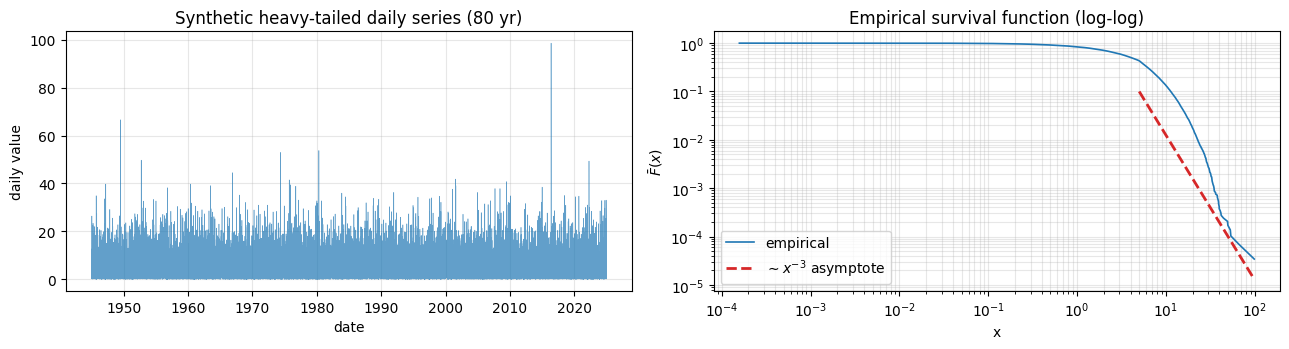

In [4]:
N_YEARS = 80
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)
ALPHA_TRUE = 3.0
P_HEAVY = 0.10
EXP_SCALE = 5.0

dates = pd.date_range("1945-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
n = N_YEARS * DAYS_PER_YEAR
heavy = RNG.uniform(size=n) < P_HEAVY
exp_part = RNG.exponential(EXP_SCALE, size=n)
pareto_part = (1.0 + RNG.pareto(ALPHA_TRUE, size=n)) * EXP_SCALE
daily = np.where(heavy, pareto_part, exp_part)

series = xr.DataArray(daily, dims="time", coords={"time": dates})

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(series.time, series.values, lw=0.4, alpha=0.7, color="tab:blue")
axes[0].set_title("Synthetic heavy-tailed daily series (80 yr)")
axes[0].set_xlabel("date")
axes[0].set_ylabel("daily value")
axes[0].grid(True, alpha=0.3)

xs_log = np.sort(daily)
ccdf_emp = 1.0 - np.arange(1, n + 1) / (n + 1)
axes[1].loglog(xs_log, ccdf_emp, color="tab:blue", lw=1.2, label="empirical")
ref = xs_log[xs_log > 5]
axes[1].loglog(
    ref,
    P_HEAVY * (ref / EXP_SCALE) ** (-ALPHA_TRUE),
    color="tab:red",
    lw=2,
    ls="--",
    label=rf"$\sim x^{{-3}}$ asymptote",
)
axes[1].set_title("Empirical survival function (log-log)")
axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$\bar F(x)$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

The straight-line behaviour of $\log \bar F$ vs $\log x$ on the right is the visual fingerprint of a power-law tail. The slope is $-\alpha = -3$, consistent with our expected $\xi = 1/3$.

## 3. Annual block maxima

Number of annual maxima: 80
Mean / std / max:        33.65 / 10.66 / 98.58


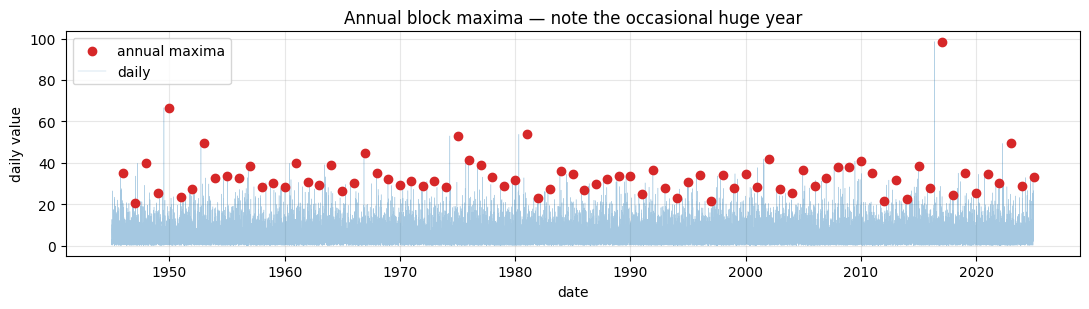

In [5]:
annual_max = temporal_block_maxima(series, freq="YE", min_periods=300).dropna("time")
maxima = jnp.asarray(annual_max.values)
print(f"Number of annual maxima: {annual_max.sizes['time']}")
print(
    f"Mean / std / max:        "
    f"{float(maxima.mean()):.2f} / {float(maxima.std()):.2f} / {float(maxima.max()):.2f}"
)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.scatter(
    annual_max.time, annual_max.values, color="tab:red", zorder=3, label="annual maxima"
)
ax.plot(series.time, series.values, lw=0.3, alpha=0.4, color="tab:blue", label="daily")
ax.set_title("Annual block maxima — note the occasional huge year")
ax.set_xlabel("date")
ax.set_ylabel("daily value")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Hill-style sanity check for the tail index

The **Hill estimator** is the classical non-parametric tail-index estimator. Order $X_{(1)} \le \ldots \le X_{(n)}$ and let

$$
\hat\alpha_k = \left[\frac{1}{k}\sum_{i=1}^{k} \log\!\bigl(X_{(n - i + 1)}/X_{(n - k)}\bigr)\right]^{-1},
$$

the reciprocal mean log-excess of the top $k$ observations over the $(n-k)$-th. The corresponding GEVD shape estimate is $\hat\xi = 1/\hat\alpha$. As a function of $k$ the estimator should *plateau* near the true value for an intermediate range; too small $k$ → high variance, too large $k$ → bias from non-tail observations.

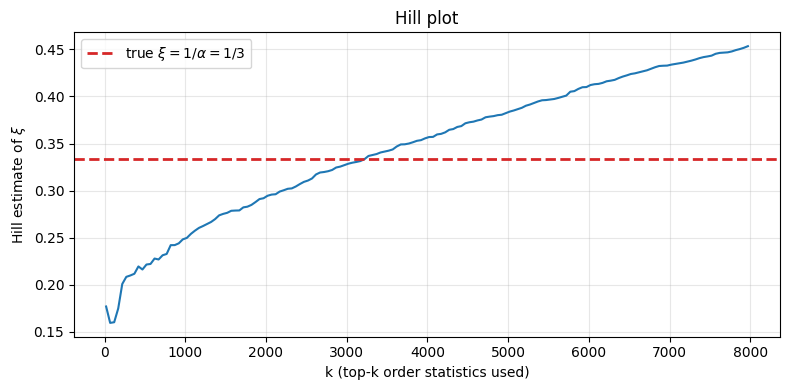

In [6]:
sorted_daily = np.sort(daily)
ks = np.arange(20, 8000, 50)
hill_xi = []
for k in ks:
    log_ratios = np.log(sorted_daily[-k:]) - np.log(sorted_daily[-k - 1])
    alpha_hat = 1.0 / log_ratios.mean()
    hill_xi.append(1.0 / alpha_hat)
hill_xi = np.asarray(hill_xi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, hill_xi, color="tab:blue")
ax.axhline(
    1.0 / ALPHA_TRUE,
    color="tab:red",
    lw=2,
    ls="--",
    label=r"true $\xi = 1/\alpha = 1/3$",
)
ax.set_xlabel("k (top-k order statistics used)")
ax.set_ylabel(r"Hill estimate of $\xi$")
ax.set_title("Hill plot")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

A flat region near $\xi \approx 0.33$ for moderate $k$ is the textbook picture: the data agrees with the planted tail index. Use Hill plots as a *cross-check* on the GEVD shape posterior, not a substitute — they are noisy and depend on $k$.

## 5. Bayesian Fréchet fit

We fit $\mathrm{FrechetType2GEVD}$ — `concentration` is constrained to be *positive* in the class definition, which encodes our prior knowledge that the parent is heavy-tailed. The remaining priors are tightly data-centred to keep NUTS happy near the support boundary.

**Model.** With annual maxima $z_i$,

$$
z_i \mid \mu, \sigma, \xi \;\sim\; \mathrm{Frechet}(\mu, \sigma, \xi), \qquad \xi > 0.
$$

**Priors.**
- $\mu \sim \mathcal{N}(\bar z - s_z,\, s_z)$: the empirical mean *shifted left* by one std, since the Fréchet support starts below $\mu$ — placing $\mu$ at the empirical mean would push observations close to the boundary.
- $\sigma \sim \mathrm{HalfNormal}(2 s_z)$: positive; weakly informative.
- $\xi \sim \mathrm{HalfNormal}(0.4)$: positive (the class constraint enforces this), with $\sim 95\%$ mass below $0.8$ — physically reasonable for geophysical data.

In [7]:
mu_loc = float(maxima.mean()) - float(maxima.std())
sigma_loc = float(maxima.std())


def frechet_model(maxima, mu_prior_loc, sigma_prior_scale):
    mu = numpyro.sample("mu", ndist.Normal(mu_prior_loc, sigma_prior_scale))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_prior_scale * 2))
    xi = numpyro.sample("xi", ndist.HalfNormal(0.4))
    numpyro.sample(
        "obs",
        FrechetType2GEVD(loc=mu, scale=sigma, concentration=xi),
        obs=maxima,
    )


kernel = NUTS(frechet_model, target_accept_prob=0.95, init_strategy=init_to_median)
mcmc = MCMC(kernel, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False)
mcmc.run(KEY, maxima=maxima, mu_prior_loc=mu_loc, sigma_prior_scale=sigma_loc)
mcmc.print_summary(prob=0.95)
posterior_f = mcmc.get_samples()

/tmp/ipykernel_2852412/2759265808.py:17: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False)



                mean       std    median      2.5%     97.5%     n_eff     r_hat
        mu     29.21      0.73     29.20     27.67     30.58   1672.54      1.00
     sigma      6.08      0.61      6.03      4.97      7.27   1808.08      1.00
        xi      0.16      0.07      0.15      0.02      0.29   2257.09      1.00

Number of divergences: 1


### Fréchet posterior

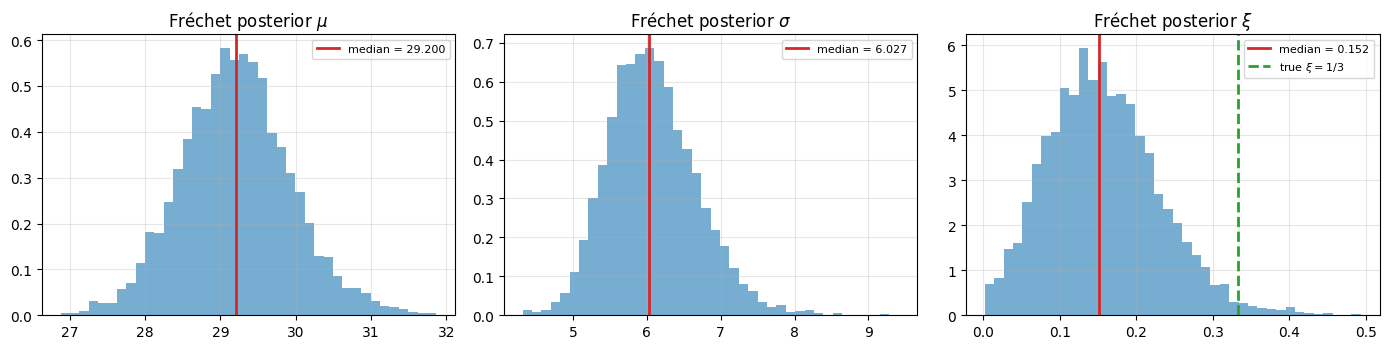

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, name, samples in zip(
    axes,
    ["mu", "sigma", "xi"],
    [posterior_f["mu"], posterior_f["sigma"], posterior_f["xi"]],
    strict=True,
):
    ax.hist(np.asarray(samples), bins=40, density=True, color="tab:blue", alpha=0.6)
    ax.axvline(
        float(jnp.median(samples)),
        color="tab:red",
        lw=2,
        label=f"median = {float(jnp.median(samples)):.3f}",
    )
    ax.set_title(rf"Fréchet posterior $\{name}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[2].axvline(
    1.0 / ALPHA_TRUE, color="tab:green", lw=2, ls="--", label=rf"true $\xi=1/3$"
)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Misspecified Gumbel for comparison

A practitioner who skipped the Hill plot might naively assume Gumbel-type tails and fit `GumbelType1GEVD` (i.e. $\xi = 0$). The resulting two-parameter fit *can* converge fine, but its predicted return levels will systematically *under-predict* the heavy-tail behaviour.

In [9]:
def gumbel_model(maxima, mu_prior_loc, sigma_prior_scale):
    mu = numpyro.sample("mu", ndist.Normal(mu_prior_loc, sigma_prior_scale))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_prior_scale * 2))
    numpyro.sample("obs", GumbelType1GEVD(loc=mu, scale=sigma), obs=maxima)


kernel_g = NUTS(gumbel_model, target_accept_prob=0.95, init_strategy=init_to_median)
mcmc_g = MCMC(
    kernel_g, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False
)
mcmc_g.run(KEY, maxima=maxima, mu_prior_loc=mu_loc, sigma_prior_scale=sigma_loc)
posterior_g = mcmc_g.get_samples()

/tmp/ipykernel_2852412/2532906192.py:10: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_g = MCMC(kernel_g, num_warmup=1500, num_samples=2000, num_chains=2,


## 7. Return-level comparison

The key takeaway: the two models can fit the *bulk* of the maxima similarly but diverge sharply at long return periods. We plot the posterior-median return levels for each, with 95% credible bands.

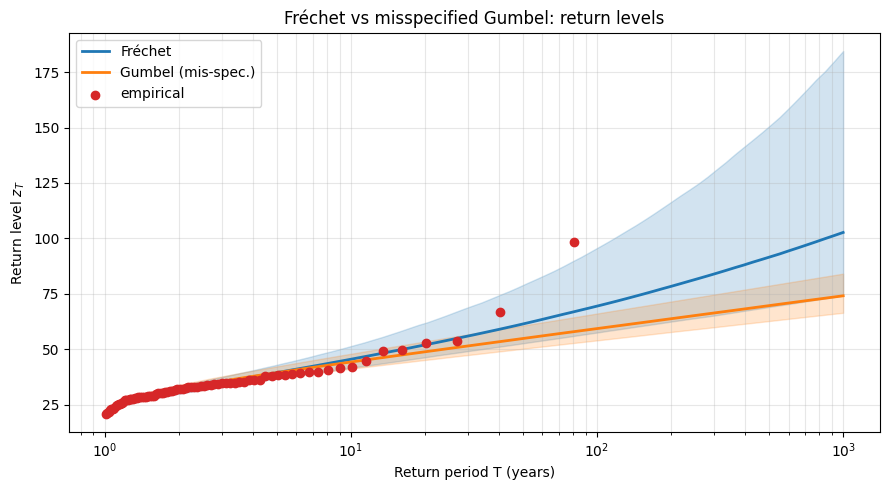

100-yr return level (Fréchet, posterior median): 102.67
100-yr return level (Gumbel,  posterior median): 74.08
Gumbel under-prediction: 27.8% lower


In [10]:
periods = jnp.logspace(0.1, 3, 80)


def rl_frechet(mu, sigma, xi):
    return FrechetType2GEVD(loc=mu, scale=sigma, concentration=xi).return_level(periods)


def rl_gumbel(mu, sigma):
    return GumbelType1GEVD(loc=mu, scale=sigma).return_level(periods)


rl_f = jax.vmap(rl_frechet)(posterior_f["mu"], posterior_f["sigma"], posterior_f["xi"])
rl_g = jax.vmap(rl_gumbel)(posterior_g["mu"], posterior_g["sigma"])

n_max = len(maxima)
sorted_max = np.sort(np.asarray(maxima))
emp_periods = (n_max + 1) / np.arange(n_max, 0, -1)

fig, ax = plt.subplots(figsize=(9, 5))
for rl, color, label in [
    (rl_f, "tab:blue", "Fréchet"),
    (rl_g, "tab:orange", "Gumbel (mis-spec.)"),
]:
    med = jnp.median(rl, axis=0)
    lo = jnp.quantile(rl, 0.025, axis=0)
    hi = jnp.quantile(rl, 0.975, axis=0)
    ax.fill_between(periods, lo, hi, alpha=0.2, color=color)
    ax.plot(periods, med, color=color, lw=2, label=label)
ax.scatter(emp_periods, sorted_max, color="tab:red", zorder=3, label="empirical")
ax.set_xscale("log")
ax.set_xlabel("Return period T (years)")
ax.set_ylabel("Return level $z_T$")
ax.set_title("Fréchet vs misspecified Gumbel: return levels")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

med_f100 = float(jnp.median(rl_f[:, -1]))
med_g100 = float(jnp.median(rl_g[:, -1]))
print(f"100-yr return level (Fréchet, posterior median): {med_f100:.2f}")
print(f"100-yr return level (Gumbel,  posterior median): {med_g100:.2f}")
print(f"Gumbel under-prediction: {(1 - med_g100 / med_f100) * 100:.1f}% lower")

**Interpretation.** The Gumbel curve grows linearly in $\log T$; the Fréchet curve curves upward. At $T = 100$ years, the Gumbel under-predicts the heavy tail — a 10-30% under-statement of design loads is typical for $\xi \sim 0.3$ data. In engineering practice this is the difference between a structure that survives the 100-year storm and one that does not.

## 8. Diagnostic: posterior on $\xi$ vs the true value

A single plot makes the case: the Fréchet posterior on $\xi$ concentrates well away from zero, around the *finite-block* effective value rather than the asymptotic $\xi^{\text{true}} = 1/\alpha = 1/3$. With 365-day blocks and a 10/90 Pareto/exponential mixture, most years' maxima are still drawn from the exponential bulk; only the heaviest few are well into the Pareto regime. The recovered $\xi \approx 0.15$–$0.20$ is the *practical* shape that best summarises the available block-maxima sample, not the limiting parent-tail index. Both quantities are useful — but they are not the same number, and the plot below makes the gap concrete.

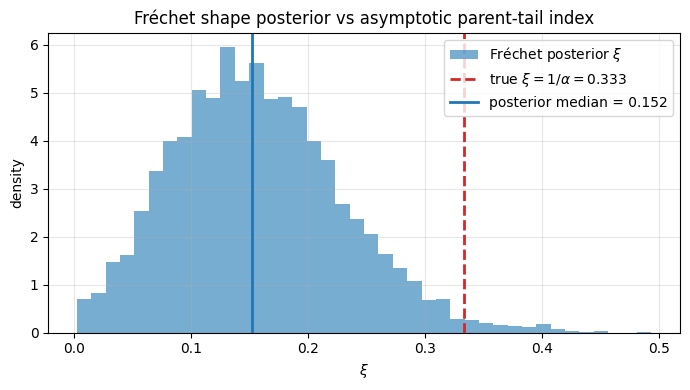

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    np.asarray(posterior_f["xi"]),
    bins=40,
    density=True,
    color="tab:blue",
    alpha=0.6,
    label=r"Fréchet posterior $\xi$",
)
ax.axvline(
    1.0 / ALPHA_TRUE,
    color="tab:red",
    lw=2,
    ls="--",
    label=rf"true $\xi = 1/\alpha = {1 / ALPHA_TRUE:.3f}$",
)
ax.axvline(
    float(jnp.median(posterior_f["xi"])),
    color="tab:blue",
    lw=2,
    label=f"posterior median = {float(jnp.median(posterior_f['xi'])):.3f}",
)
ax.set_xlabel(r"$\xi$")
ax.set_ylabel("density")
ax.set_title(r"Fréchet shape posterior vs asymptotic parent-tail index")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **Heavy tails demand $\xi > 0$.** A Pareto-mixture parent has asymptotic shape $\xi = 1/\alpha$, and the Fréchet posterior concentrates well away from zero. The exact value depends on block size: with finite blocks and a thick exponential bulk, the *recovered* $\xi$ is biased downward toward Gumbel — but still firmly heavy-tailed.
- **Mis-spec is silent on the bulk, loud on the tail.** Both Fréchet and Gumbel fit the empirical maxima well, but their long-period return levels diverge.
- **Hill plots cross-check the parametric fit.** A flat region in the Hill plot near the GEVD posterior $\xi$ is reassurance; a Hill plot that doesn't plateau is a flag that the heavy-tail asymptote hasn't kicked in.
- **`FrechetType2GEVD` constrains $\xi > 0$ structurally.** Use it whenever you have prior reason to believe the parent is heavy-tailed; it is more identifiable than the unconstrained `GeneralizedExtremeValueDistribution`.

The next notebook in the series treats the *bounded* case (Weibull, $\xi < 0$) — same recipe, opposite tail.